In [1]:
import numpy as np
import pandas as pd
import requests
import time

from scipy.sparse import hstack
from scipy.stats import spearmanr

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
import tensorflow as tf
from tensorflow.keras import layers

import powerlaw

import os

os.makedirs("plots", exist_ok=True)

In [2]:
def decode_abstract(inv_index):
    if not inv_index:
        return ""
    words = []
    for word, positions in inv_index.items():
        for pos in positions:
            words.append((pos, word))
    words = sorted(words)
    return " ".join([w for _, w in words])


def fetch_openalex_data(n_pages=30):
    works = []
    base_url = "https://api.openalex.org/works"
    cursor = "*"

    for i in range(n_pages):
        print(f"Fetching page {i+1}...")

        params = {
            "filter": "from_publication_date:2015-01-01,to_publication_date:2018-12-31",
            "per_page": 200,
            "cursor": cursor
        }

        response = requests.get(base_url, params=params)

        if response.status_code != 200:
            print("Error:", response.text)
            break

        data = response.json()

        for work in data["results"]:
            works.append({
                "id": work.get("id"),
                "title": work.get("title"),
                "abstract": decode_abstract(work.get("abstract_inverted_index")),
                "year": work.get("publication_year"),
                "num_authors": len(work.get("authorships", [])),
                "num_references": len(work.get("referenced_works", [])),
                "citation_count": work.get("cited_by_count"),
                "references": work.get("referenced_works"),
                "field": work.get("primary_topic", {}).get("display_name")
            })

        cursor = data["meta"].get("next_cursor")
        if not cursor:
            break

        time.sleep(1)

    return pd.DataFrame(works)


df = fetch_openalex_data(n_pages=30)

Fetching page 1...
Fetching page 2...
Fetching page 3...
Fetching page 4...
Fetching page 5...
Fetching page 6...
Fetching page 7...
Fetching page 8...
Fetching page 9...
Fetching page 10...
Fetching page 11...
Fetching page 12...
Fetching page 13...
Fetching page 14...
Fetching page 15...
Fetching page 16...
Fetching page 17...
Fetching page 18...
Fetching page 19...
Fetching page 20...
Fetching page 21...
Fetching page 22...
Fetching page 23...
Fetching page 24...
Fetching page 25...
Fetching page 26...
Fetching page 27...
Fetching page 28...
Fetching page 29...
Fetching page 30...


Just the imports, requests will be for "openalex"

In [3]:
df = df.dropna(subset=["title", "year", "citation_count"])
df["abstract"] = df["abstract"].fillna("")
df["field"] = df["field"].fillna("Unknown")

df["text"] = df["title"] + " " + df["abstract"]

current_year = 2024
df["age"] = current_year - df["year"] + 1

# targets
df["y"] = np.log1p(df["citation_count"])
df["early_signal"] = df["citation_count"] / df["age"]

In [4]:
df["title_len"] = df["title"].apply(lambda x: len(x.split()))
df["abstract_len"] = df["abstract"].apply(lambda x: len(x.split()))

df["refs_per_author"] = df["num_references"] / (df["num_authors"] + 1)

# time
df["aging"] = np.exp(-0.1 * df["age"])

# preferential attachment
df["popularity"] = np.log1p(df["citation_count"] + 1)
df["growth_rate"] = df["citation_count"] / df["age"]

# fitness
df["fitness"] = (
    0.4 * df["abstract_len"] +
    0.3 * df["title_len"] +
    0.3 * df["num_authors"]
)

In [5]:
field_stats = df.groupby("field")["citation_count"].agg(["mean", "std"]).reset_index()
df = df.merge(field_stats, on="field", how="left")

df["citation_norm"] = (
    (df["citation_count"] - df["mean"]) /
    (df["std"] + 1e-6)
)

df["y_norm"] = df["citation_norm"]

In [6]:
G = nx.DiGraph()

print("Building graph...")

for _, row in df.iterrows():
    src = row["id"]
    refs = row["references"]

    if refs:
        for ref in refs:
            G.add_edge(ref, src)

print("Calculating PageRank...")
pagerank = nx.pagerank(G, alpha=0.85)

df["pagerank"] = df["id"].map(pagerank).fillna(0)

Building graph...
Calculating PageRank...


In [7]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")

X_text = embedder.encode(
    df["text"].tolist(),
    batch_size=64,
    show_progress_bar=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

In [8]:
numeric_cols = [
    "num_authors",
    "num_references",
    "title_len",
    "abstract_len",
    "refs_per_author",
    "aging",
    "popularity",
    "growth_rate",
    "fitness",
    "pagerank",
    "early_signal"
]

scaler = StandardScaler()
X_numeric = scaler.fit_transform(df[numeric_cols])

In [9]:
X_all = np.hstack([X_text, X_numeric])
y_all = df["y"].values

In [10]:
train_mask = (df["year"] <= 2017).values
test_mask = (df["year"] == 2018).values

X_train = X_all[train_mask]
X_test = X_all[test_mask]

y_train = y_all[train_mask]
y_test = y_all[test_mask]

print("Train:", len(y_train), "Test:", len(y_test))

Train: 4662 Test: 1338


In [11]:
xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [13]:
# Back-transform
y_test_real = np.expm1(y_test)
y_pred_xgb_real = np.expm1(y_pred_xgb)  # ← y_pred yerine y_pred_xgb yazılmalı

mae = mean_absolute_error(y_test_real, y_pred_xgb_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_xgb_real))
r2 = r2_score(y_test_real, y_pred_xgb_real)

# Ranking metric
spearman_corr = spearmanr(y_test_real, y_pred_xgb_real).correlation

print("\nRESULTS")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Spearman:", spearman_corr)


RESULTS
MAE: 121.57566790160229
RMSE: 1137.7754466273368
R²: 0.9147470169871191
Spearman: 0.9999707482453277


In [14]:
print("\nPower-law fitting...")

fit = powerlaw.Fit(df["citation_count"] + 1)

print("Alpha:", fit.power_law.alpha)
print("xmin:", fit.power_law.xmin)


Power-law fitting...
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 2620/2620 [00:00<00:00, 5150.38it/s]

Alpha: 2.8202122111904817
xmin: 1397.0



c:\Users\Gaming\Desktop\ADS_Citation\venv\Lib\site-packages\powerlaw\distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


In [15]:
nn_model = tf.keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='mse'
)

nn_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64
)

y_pred_nn = nn_model.predict(X_test).flatten()

Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 32.8335 - val_loss: 23.4958
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.1175 - val_loss: 5.1525
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1942 - val_loss: 1.1261
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0296 - val_loss: 0.3517
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8544 - val_loss: 0.1406
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8046 - val_loss: 0.0914
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7686 - val_loss: 0.0987
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7280 - val_loss: 0.1301
Epoch 9/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6493 - val_loss: 0.1278
Epoch 10/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6220 - val_loss: 0.1251
Epoch 11/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6140 - val_loss: 0.1250
Epoch 12/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5750 - val_

In [16]:
y_test_real = np.expm1(y_test)
y_pred_xgb_real = np.expm1(y_pred_xgb)
y_pred_nn_real = np.expm1(y_pred_nn)

print("\nXGB RESULTS")
print("R2:", r2_score(y_test_real, y_pred_xgb_real))
print("Spearman:", spearmanr(y_test_real, y_pred_xgb_real).correlation)

print("\nNN RESULTS")
print("R2:", r2_score(y_test_real, y_pred_nn_real))
print("Spearman:", spearmanr(y_test_real, y_pred_nn_real).correlation)


XGB RESULTS
R2: 0.9147470169871191
Spearman: 0.9999707482453277

NN RESULTS
R2: -30603.933752853383
Spearman: 0.778340477734824


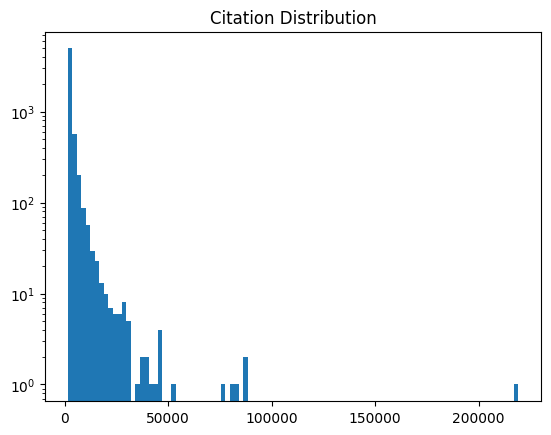

In [17]:
plt.figure()
plt.hist(df["citation_count"], bins=100, log=True)
plt.title("Citation Distribution")
plt.show()
plt.savefig("plots/citation_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

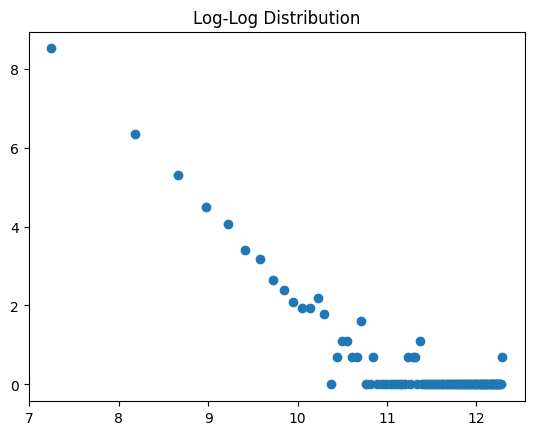

In [18]:
values = df["citation_count"] + 1
counts, bins = np.histogram(values, bins=100)

plt.figure()
plt.scatter(np.log(bins[:-1]+1), np.log(counts+1))
plt.title("Log-Log Distribution")
plt.show()
plt.savefig("plots/citation_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

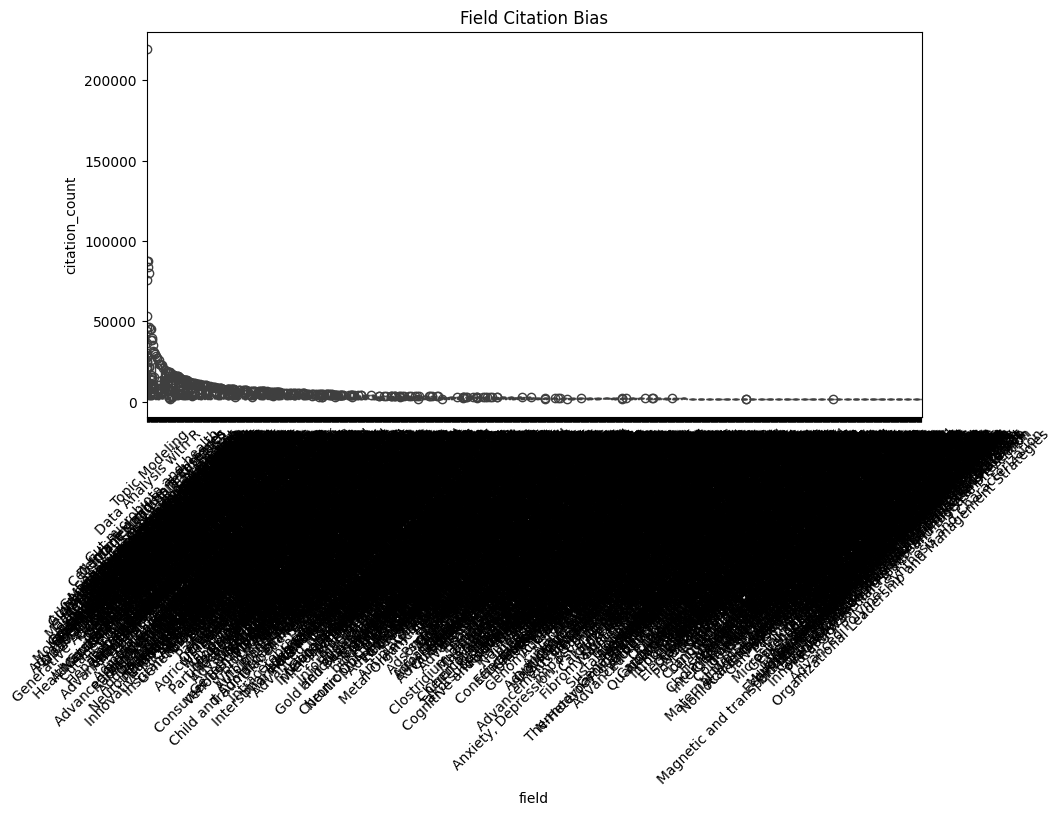

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(x="field", y="citation_count", data=df)
plt.xticks(rotation=45)
plt.title("Field Citation Bias")
plt.show()
plt.savefig("plots/citation_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

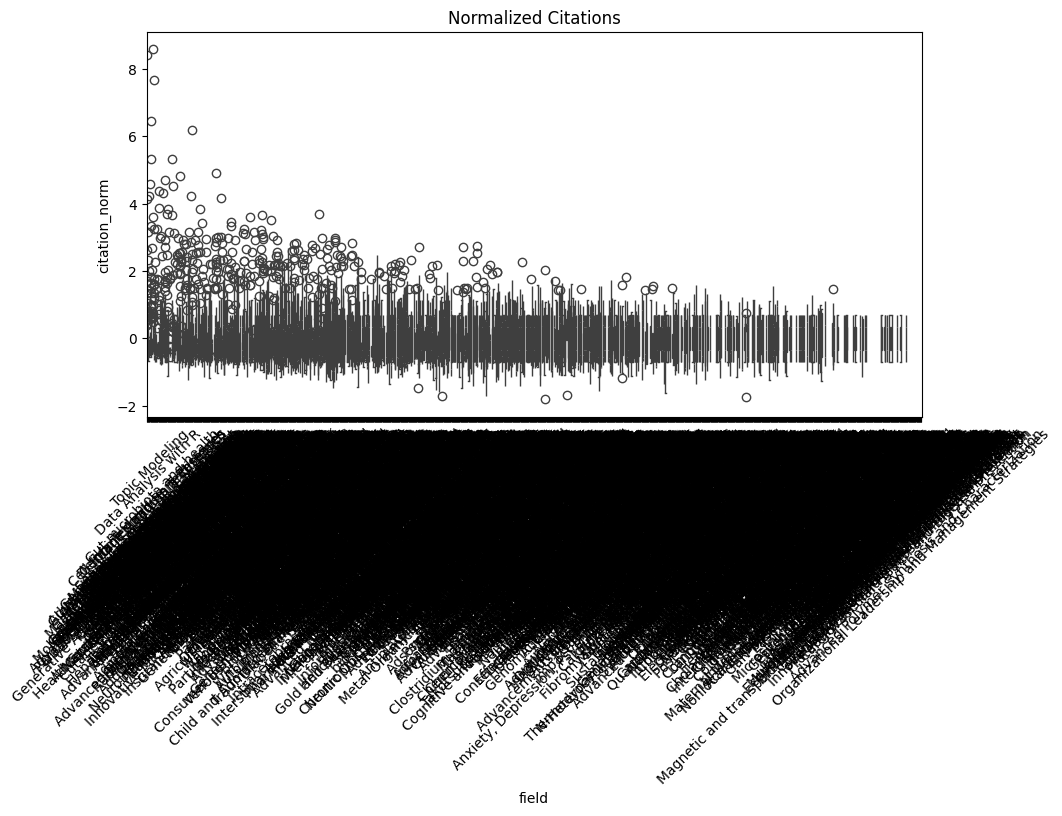

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(x="field", y="citation_norm", data=df)
plt.xticks(rotation=45)
plt.title("Normalized Citations")
plt.show()
plt.savefig("plots/citation_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

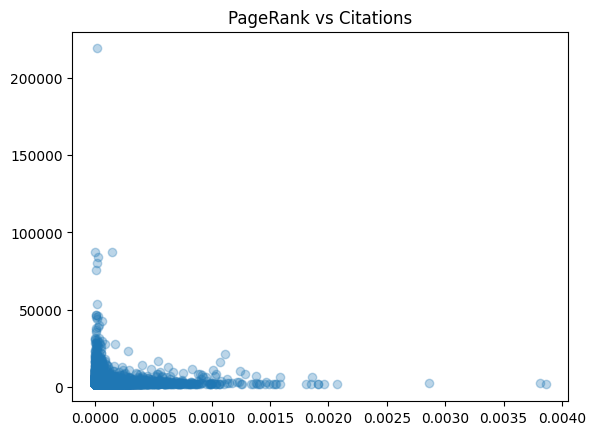

In [21]:
plt.figure()
plt.scatter(df["pagerank"], df["citation_count"], alpha=0.3)
plt.title("PageRank vs Citations")
plt.show()
plt.savefig("plots/citation_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

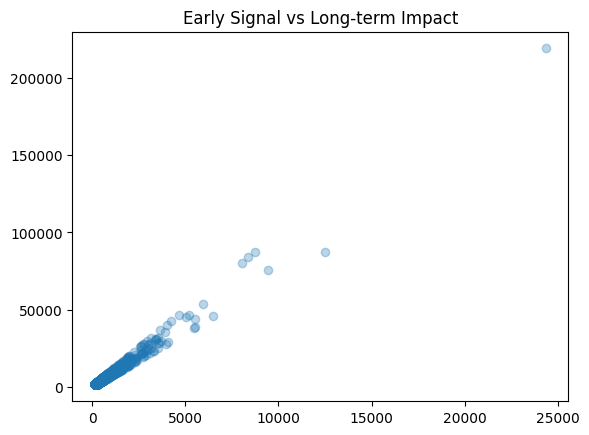

In [22]:
plt.figure()
plt.scatter(df["early_signal"], df["citation_count"], alpha=0.3)
plt.title("Early Signal vs Long-term Impact")
plt.show()
plt.savefig("plots/citation_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

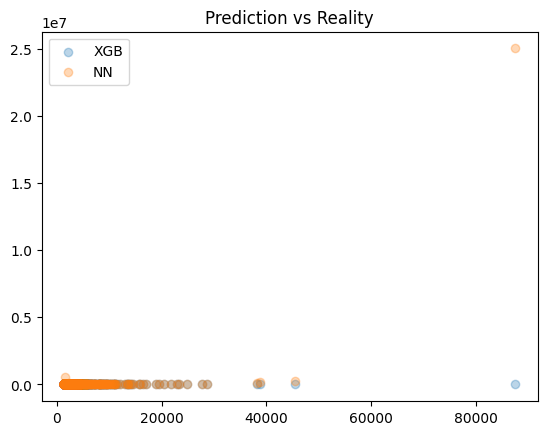

In [23]:
plt.figure()
plt.scatter(y_test_real, y_pred_xgb_real, alpha=0.3, label="XGB")
plt.scatter(y_test_real, y_pred_nn_real, alpha=0.3, label="NN")
plt.legend()
plt.title("Prediction vs Reality")
plt.show()
plt.savefig("plots/citation_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

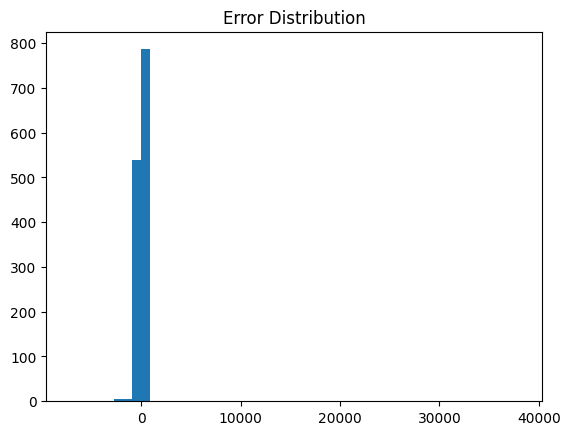

In [24]:
errors = y_test_real - y_pred_xgb_real

plt.figure()
plt.hist(errors, bins=50)
plt.title("Error Distribution")
plt.show()
plt.savefig("plots/citation_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

In [25]:
fit = powerlaw.Fit(df["citation_count"] + 1)

print("Alpha:", fit.power_law.alpha)
print("xmin:", fit.power_law.xmin)

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 2620/2620 [00:00<00:00, 4896.24it/s]

Alpha: 2.8202122111904817
xmin: 1397.0



c:\Users\Gaming\Desktop\ADS_Citation\venv\Lib\site-packages\powerlaw\distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


In [26]:
# ================================================================================
# SECTION: ADDITIONAL RESEARCH STUDIES
# ================================================================================

# RESEARCH 1: Feature Ablation Study
# Removes one feature group at a time to understand individual contributions
print("\n" + "="*60)
print("RESEARCH 1: FEATURE ABLATION STUDY")
print("="*60)

from sklearn.model_selection import cross_val_score

ablation_results = {}

# Baseline (all features)
xgb_baseline = XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_baseline.fit(X_train, y_train)
y_pred_baseline = xgb_baseline.predict(X_test)
r2_baseline = r2_score(np.expm1(y_test), np.expm1(y_pred_baseline))
ablation_results['All Features'] = r2_baseline

# Without text embeddings (only numeric)
xgb_no_text = XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42)
X_train_no_text = X_train[:, 384:]  # Remove first 384 dimensions
X_test_no_text = X_test[:, 384:]
xgb_no_text.fit(X_train_no_text, y_train)
y_pred_no_text = xgb_no_text.predict(X_test_no_text)
r2_no_text = r2_score(np.expm1(y_test), np.expm1(y_pred_no_text))
ablation_results['Without Text Embeddings'] = r2_no_text

# Without PageRank (remove 1 feature from numeric)
pagerank_idx = 9  # Index of pagerank in numeric_cols
X_train_no_pr = np.delete(X_train, 384+pagerank_idx, axis=1)
X_test_no_pr = np.delete(X_test, 384+pagerank_idx, axis=1)
xgb_no_pr = XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_no_pr.fit(X_train_no_pr, y_train)
y_pred_no_pr = xgb_no_pr.predict(X_test_no_pr)
r2_no_pr = r2_score(np.expm1(y_test), np.expm1(y_pred_no_pr))
ablation_results['Without PageRank'] = r2_no_pr

# Without temporal features (aging, growth_rate, early_signal)
temporal_indices = [5, 7, 10]  # aging, growth_rate, early_signal
X_train_no_temp = np.delete(X_train, [384+i for i in temporal_indices], axis=1)
X_test_no_temp = np.delete(X_test, [384+i for i in temporal_indices], axis=1)
xgb_no_temp = XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_no_temp.fit(X_train_no_temp, y_train)
y_pred_no_temp = xgb_no_temp.predict(X_test_no_temp)
r2_no_temp = r2_score(np.expm1(y_test), np.expm1(y_pred_no_temp))
ablation_results['Without Temporal Features'] = r2_no_temp

print("\nAblation Study Results (R² Score):")
for feature_set, r2 in ablation_results.items():
    drop = (r2_baseline - r2) if r2 != r2_baseline else 0
    drop_pct = (drop / r2_baseline * 100) if r2 != r2_baseline else 0
    print(f"  {feature_set}: R²={r2:.4f} (drop: {drop:.4f} / {drop_pct:.2f}%)")

# Visualize ablation
plt.figure(figsize=(10, 6))
features = list(ablation_results.keys())
r2_scores = list(ablation_results.values())
colors = ['green' if f == 'All Features' else 'coral' for f in features]
plt.bar(features, r2_scores, color=colors, alpha=0.7)
plt.ylabel('R² Score')
plt.title('Feature Ablation Study: Impact on Model Performance')
plt.xticks(rotation=45, ha='right')
plt.ylim([min(r2_scores) - 0.05, max(r2_scores) + 0.05])
plt.tight_layout()
plt.savefig("plots/ablation_study.png", dpi=300, bbox_inches='tight')
plt.close()
print("\n✓ Ablation study plot saved to plots/ablation_study.png")



RESEARCH 1: FEATURE ABLATION STUDY

Ablation Study Results (R² Score):
  All Features: R²=0.9100 (drop: 0.0000 / 0.00%)
  Without Text Embeddings: R²=0.8131 (drop: 0.0969 / 10.65%)
  Without PageRank: R²=0.8937 (drop: 0.0163 / 1.79%)
  Without Temporal Features: R²=0.7948 (drop: 0.1151 / 12.65%)

✓ Ablation study plot saved to plots/ablation_study.png


In [28]:
# Load and run advanced research
exec(open('advanced_research.py').read())

ADVANCED RESEARCH STUDIES FOR CITATION PREDICTION

[1/8] FEATURE ABLATION STUDY
----------------------------------------------------------------------
Training baseline model with all features...
Baseline RÂ²: 0.9100
Training model WITHOUT text embeddings (11 numeric features)...
No Text Embeddings RÂ²: 0.8131 (drop: 0.0969)
Training model WITHOUT PageRank (394 features)...
No PageRank RÂ²: 0.8937 (drop: 0.0163)
Training model WITHOUT temporal features (392 features)...
No Temporal Features RÂ²: 0.7948 (drop: 0.1151)
Training model with ONLY text embeddings (384 features)...
Text Only RÂ²: 0.0659

ABLATION STUDY SUMMARY (RÂ² Scores):
  All Features (395)...................... 0.9100  âœ“ BASELINE
  Without Text Embeddings (11)............ 0.8131  â†“ 0.0969 (10.7%)
  Without PageRank (394).................. 0.8937  â†“ 0.0163 (1.8%)
  Without Temporal (392).................. 0.7948  â†“ 0.1151 (12.7%)
  Only Text Embeddings (384).............. 0.0659  â†“ 0.8441 (92.8%)

âœ“ Saved: plo